### **UNAD**
### **Análisis de datos**
### **Fabián Andres Peña Gonzalez**
### **Predicción de enfermedad cardiaca con regresión logística**

#### **1. Realizar un análisis exploratorio de los datos para identificar relaciones entre variables, valores atípicos, tendencias, etc.**

In [321]:
#Cargar las librerias necesarias

import pandas as pd # Manejo y análisis de estructuras de datos
import numpy as np # Cálculo numérico y el análisis de datos 
import seaborn as sns # Creación gráficos estadísticos
import matplotlib.pyplot as plt # Creación de gráficos en dos dimensiones

# librerías de para implementar modelos de ciencia de datos
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [323]:
# lectura de datos en Python y lo cargamos en la variable Datos

Datos = pd.read_csv('C:/Unad/heart_cleveland_upload.csv')

In [325]:
# Realizamos lectura de los Datos para el análisis exploratorio

Datos.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0
5,64,1,0,170,227,0,2,155,0,0.6,1,0,2,0
6,63,1,0,145,233,1,2,150,0,2.3,2,0,1,0
7,61,1,0,134,234,0,0,145,0,2.6,1,2,0,1
8,60,0,0,150,240,0,0,171,0,0.9,0,0,0,0
9,59,1,0,178,270,0,2,145,0,4.2,2,0,2,0


In [327]:
# Descripción de los datos
Datos.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

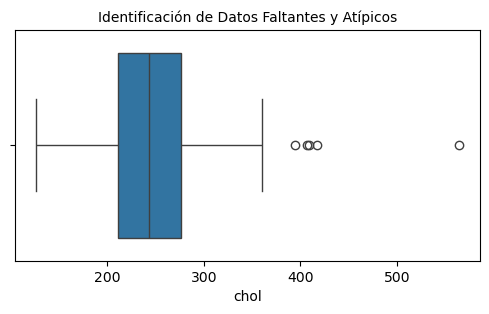

In [329]:
#Identificación de Datos Faltantes y Atípicos

plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['chol'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

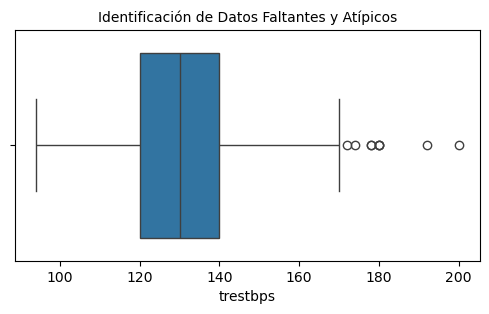

In [330]:
#Identificación de Datos Faltantes y Atípicos

plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['trestbps'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

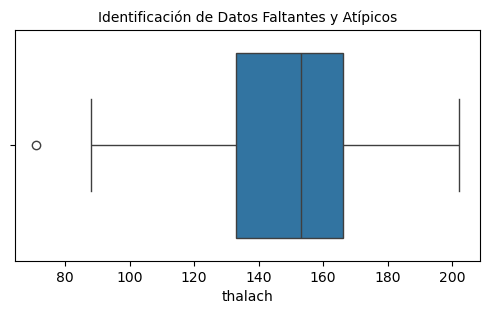

In [332]:
#Identificación de Datos Faltantes y Atípicos

plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['thalach'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

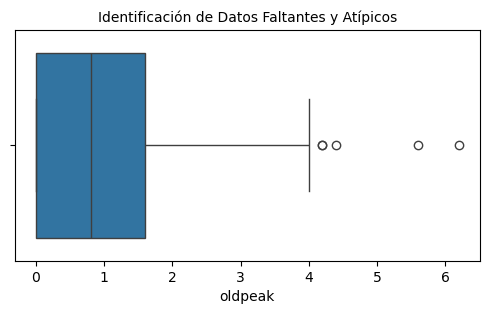

In [334]:
#Identificación de Datos Faltantes y Atípicos

plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['oldpeak'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

#### **2. Preprocesar los datos limpiándolos, tratando valores faltantes y transformándolos según sea necesario**

In [337]:
#Revisión de datos faltantes

print("Cantidad de Registros con cero en Edad : ",Datos['age'].isin([0]).sum())
print("Cantidad de Registros con cero en Presión Arterial: ",Datos['trestbps'].isin([0]).sum())
print("Cantidad de Registros con cero en Colesterol: ",Datos['chol'].isin([0]).sum())
print("Cantidad de Registros con cero en Nivel Frecuencia Cardiaca: ",Datos['thalach'].isin([0]).sum())


Cantidad de Registros con cero en Edad :  0
Cantidad de Registros con cero en Presión Arterial:  0
Cantidad de Registros con cero en Colesterol:  0
Cantidad de Registros con cero en Nivel Frecuencia Cardiaca:  0


In [339]:
#Conteo de Datos Atípicos

nivel_minimo=80
nivel_maximo=180
Total_Atipicos=((Datos['trestbps']<nivel_minimo)|(Datos['trestbps']>nivel_maximo)).sum()
print("El total de datos atípicos en presion arterial es: {}".format(Total_Atipicos))

El total de datos atípicos en presion arterial es: 2


In [342]:
# Filtra Datos Atípicos

Datos=Datos[(Datos['trestbps']<nivel_maximo)&(Datos['trestbps']>nivel_minimo)]

In [344]:
# Validar si se removieron los datos atípicos

Total_Atipicos=((Datos['trestbps']<nivel_minimo)|(Datos['trestbps']>nivel_maximo)).sum()
print("El total de datos atípicos en presion arterial es: {}".format(Total_Atipicos))

El total de datos atípicos en presion arterial es: 0


In [397]:
#Conteo de Datos Atípicos

nivel_minimo=100
nivel_maximo=400
Total_Atipicos=((Datos['chol']<nivel_minimo)|(Datos['chol']>nivel_maximo)).sum()
print("El total de datos atípicos en colesterol es: {}".format(Total_Atipicos))

El total de datos atípicos en colesterol es: 0


In [348]:
# Filtra Datos Atípicos

Datos=Datos[(Datos['chol']<nivel_maximo)&(Datos['chol']>nivel_minimo)]

In [399]:
# Validar si se removieron los datos atípicos

Total_Atipicos=((Datos['trestbps']<nivel_minimo)|(Datos['trestbps']>nivel_maximo)).sum()
print("El total de datos atípicos en colesterol es: {}".format(Total_Atipicos))

El total de datos atípicos en colesterol es: 0


In [352]:
#Conteo de Datos Atípicos

nivel_minimo=60
nivel_maximo=190
Total_Atipicos=((Datos['thalach']<nivel_minimo)|(Datos['thalach']>nivel_maximo)).sum()
print("El total de datos atípicos en frecuencia cardiaca es: {}".format(Total_Atipicos))

El total de datos atípicos en frecuencia cardiaca es: 3


In [354]:
# Filtra Datos Atípicos

Datos=Datos[(Datos['thalach']<nivel_maximo)&(Datos['thalach']>nivel_minimo)]

In [356]:
# Validar si se removieron los datos atípicos

Total_Atipicos=((Datos['thalach']<nivel_minimo)|(Datos['thalach']>nivel_maximo)).sum()
print("El total de datos atípicos en frecuencia cardiaca es: {}".format(Total_Atipicos))

El total de datos atípicos en frecuencia cardiaca es: 0


In [358]:
#Conteo de Datos Atípicos

nivel_minimo=0
nivel_maximo=4
Total_Atipicos=((Datos['oldpeak']<nivel_minimo)|(Datos['oldpeak']>nivel_maximo)).sum()
print("El total de datos atípicos en depresión del segmento ST es: {}".format(Total_Atipicos))

El total de datos atípicos en depresión del segmento ST es: 5


In [360]:
# Filtra Datos Atípicos

Datos=Datos[(Datos['oldpeak']<nivel_maximo)&(Datos['oldpeak']>nivel_minimo)]

In [362]:
# Validar si se removieron los datos atípicos

Total_Atipicos=((Datos['oldpeak']<nivel_minimo)|(Datos['oldpeak']>nivel_maximo)).sum()
print("El total de datos atípicos en depresión del segmento ST es: {}".format(Total_Atipicos))

El total de datos atípicos en depresión del segmento ST es: 0


In [364]:
#Revisión del tipo de datos y datos faltantes

Datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186 entries, 0 to 295
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        186 non-null    int64  
 1   sex        186 non-null    int64  
 2   cp         186 non-null    int64  
 3   trestbps   186 non-null    int64  
 4   chol       186 non-null    int64  
 5   fbs        186 non-null    int64  
 6   restecg    186 non-null    int64  
 7   thalach    186 non-null    int64  
 8   exang      186 non-null    int64  
 9   oldpeak    186 non-null    float64
 10  slope      186 non-null    int64  
 11  ca         186 non-null    int64  
 12  thal       186 non-null    int64  
 13  condition  186 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 21.8 KB


#### **3.Seleccionar las características más relevantes para entrenar el modelo utilizando selección de características**

Característica de interes:<br>
condición: 0 = sin enfermedad, 1 = enfermedad

In [368]:
# Total de personas con enfermedad cardiaca

Datos['condition'].value_counts()

condition
1    101
0     85
Name: count, dtype: int64

#### **4. Dividir el dataset en Train y Test para evaluar correctamente el modelo**

In [371]:
# Porcentaje de datos para entrenamiento (train) = 70% , y para prueba (test) = 30%

# Se crean variables X y Y para almacenar la información del entrenamiento

X = Datos.drop('condition',axis=1) # Se cargan los datos de train sin los datos de la columna Diabetico 
Y = Datos['condition'] # Se cargan los datos de train con los datos de la la columna Diabetico

#La función train_test_split crea una división de un conjunto de datos en dos bloques uno de entrenamiento y otro de prueba (train and test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=Y, random_state= 0)

In [373]:
print (X_train)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
5     64    1   0       170   227    0        2      155      0      0.6   
97    59    1   2       150   212    1        0      157      0      1.6   
38    56    1   1       120   236    0        0      178      0      0.8   
240   55    1   3       132   353    0        0      132      1      1.2   
153   37    1   2       130   250    0        0      187      0      3.5   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
75    69    1   2       140   254    0        2      146      0      2.0   
189   62    0   3       138   294    1        0      106      0      1.9   
256   52    1   3       108   233    1        0      147      0      0.1   
174   64    1   3       120   246    0        2       96      1      2.2   
18    45    1   0       110   264    0        0      132      0      1.2   

     slope  ca  thal  
5        1   0     2  
97       0   0     0  
38       0   0    

In [375]:
print (X_test)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
285   43    1   3       150   247    0        0      171      0      1.5   
170   65    0   3       150   225    0        2      114      0      1.0   
193   61    0   3       145   307    0        2      146      1      1.0   
120   51    1   2       110   175    0        0      123      0      0.6   
181   63    0   3       108   269    0        0      169      1      1.8   
252   53    1   3       123   282    0        0       95      1      2.0   
156   71    0   3       112   149    0        0      125      0      1.6   
235   56    1   3       130   283    1        2      103      1      1.6   
119   51    1   2       125   245    1        2      166      0      2.4   
208   59    1   3       110   239    0        2      142      1      1.2   
224   57    1   3       150   276    0        2      112      1      0.6   
20    40    1   0       140   199    0        0      178      1      1.4   
12    59    

#### **5. Entrenar el modelo configurando los diferentes hiperparámetros**

In [378]:
# Construir el modelo de regresión logística 

modelo_regresion = LogisticRegression(solver = "liblinear") # liblinear es una libreria para resolver problemas lineales de clasificación y regresión
modelo_regresion.fit (X_train , Y_train)   

# Crea el modelo de prediccion
Prediccion = modelo_regresion.predict(X_test) # la función predict predice los valores a partir del conjunto de datos de validación    

In [380]:
X_test.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
285,43,1,3,150,247,0,0,171,0,1.5,0,0,0
170,65,0,3,150,225,0,2,114,0,1.0,1,3,2
193,61,0,3,145,307,0,2,146,1,1.0,1,0,2
120,51,1,2,110,175,0,0,123,0,0.6,0,0,0
181,63,0,3,108,269,0,0,169,1,1.8,1,2,0
252,53,1,3,123,282,0,0,95,1,2.0,1,2,2
156,71,0,3,112,149,0,0,125,0,1.6,1,0,0
235,56,1,3,130,283,1,2,103,1,1.6,2,0,2
119,51,1,2,125,245,1,2,166,0,2.4,1,0,0
208,59,1,3,110,239,0,2,142,1,1.2,1,1,2


In [382]:
print (Prediccion)

[0 1 1 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 0 1 1 1 1 0 1 0 1 1 0 1 1 1 0 1 1 0 0
 0 1 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 1 1]


#### **6. Evaluar el desempeño del modelo en el conjunto de Test con métricas como precisión, recall, F1-score, etc**

In [385]:
# Desempeño del modelo de regresión

print(classification_report(Y_test,Prediccion))

              precision    recall  f1-score   support

           0       0.76      0.85      0.80        26
           1       0.85      0.77      0.81        30

    accuracy                           0.80        56
   macro avg       0.81      0.81      0.80        56
weighted avg       0.81      0.80      0.80        56



#### **7. Realizar las diferentes gráficas que permitan visualizar los resultados del modelo**


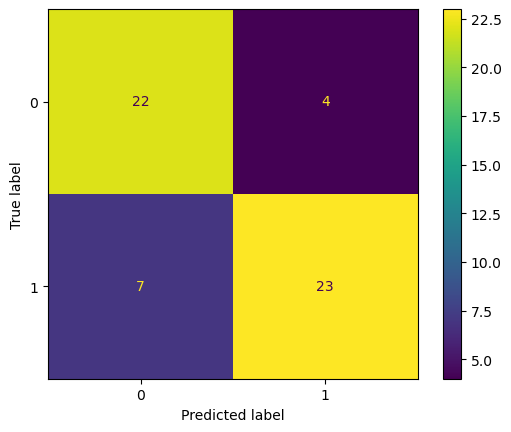

In [388]:
#Matrix de Confusión del modelo

cm=confusion_matrix(Y_test,Prediccion)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

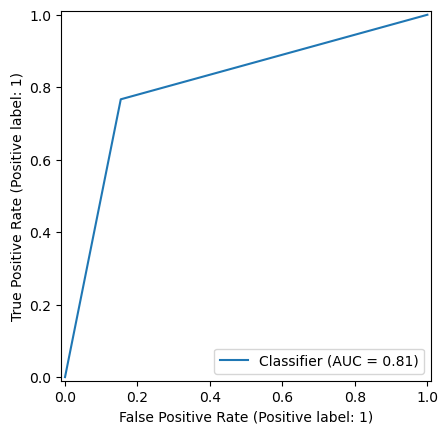

In [389]:
# Curva de precisón del modelo

from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(Y_test, Prediccion)
plt.show()

#### **8. Interpretar, analizar y documentar los resultados obtenidos**

Del desempeño del modelo se puede describir:

Precisión: Precisión mide la proporción de predicciones positivas verdaderas entre todas las predicciones positivas realizadas por el modelo. Aquí la precisión para la clase "condition" es 0,85 lo que significa que el 85% de los predichos con presencia de enfermedad cardiaca por el modelo eran en realidad enfermos.

Recall: Mide la proporción de predicciones positivas verdaderas entre todas las instancias positivas reales en el conjunto de datos. Aquí el Recall para la clase "condition" es 0,77, lo que indica que el modelo identificó correctamente al 77% de todos los enfermos cardiacos.

F1 Score: Es la media armónica de precisión y recall. Proporciona una puntuación única que equilibra la precisión y recall. Aquí la puntuación F1 para la clase "condition" es 0,81, lo que indica un buen equilibrio entre precisión y recall.

De la Matriz de Confusión podemos interpretar:

Verdaderos negativos: el recuento de observaciones que un clasificador predijo correctamente como falso 22

Verdaderos positivos: el recuento de observaciones que un clasificador predijo correctamente como Verdadero 23

Falsos positivos: el recuento de observaciones que un clasificador predijo incorrectamente como Verdaderas 4

Falsos negativos: el recuento de observaciones que un clasificador predijo incorrectamente como falso 7

De la curva de precisión del modelo se puede interpretar:

El AUC es 0,81 lo que significa que el 81% de las predicciones del clasificador son correctas en todos los umbrales de clasificación.